# Diabetes Risk Prediction - Análise e Classificação de dados usando Scikit-Learn, Pandas e Seaborn.

por Pedro Arthur Gomes Maia

In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Bibliotecas importadas")

Bibliotecas importadas


Importando o dataset.

In [84]:
data = pd.read_csv("diabetes_risk.csv")
print("Dataset importado")

Dataset importado


# Análise e Exploração dos Dados

In [85]:
data.shape

(15000, 19)

In [86]:
data.columns

Index(['patient_id', 'age', 'gender', 'city', 'bmi', 'family_history_diabetes',
       'physical_activity_level', 'diet_type', 'smoking_status',
       'alcohol_consumption', 'hours_sleep_per_night', 'stress_level',
       'fasting_blood_sugar', 'hba1c_level', 'blood_pressure_systolic',
       'blood_pressure_diastolic', 'waist_circumference_cm', 'income_bracket',
       'diabetes_risk'],
      dtype='str')

In [87]:
data.head()

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


In [88]:
data.describe()

,patient_id,age,bmi,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,44.333667,23.062260,7.309860,5.941200,168.789933,6.878387,139.496200,86.256933,100.207933
std,4330.271354,10.383753,4.046391,1.109372,2.148406,38.365822,0.843276,12.660785,8.386529,10.760331
min,1.000000,18.000000,15.000000,3.000000,1.000000,72.000000,4.800000,80.000000,50.000000,73.200000
25%,3750.750000,38.000000,20.100000,6.700000,4.000000,145.000000,6.300000,130.000000,80.000000,92.500000
50%,7500.500000,45.000000,22.700000,7.000000,6.000000,165.000000,6.800000,140.000000,88.000000,99.300000
75%,11250.250000,52.000000,25.600000,8.000000,7.000000,189.000000,7.300000,150.000000,90.000000,106.900000
max,15000.000000,80.000000,40.800000,12.000000,10.000000,400.000000,13.400000,200.000000,120.000000,148.200000


In [89]:
data.describe(include=['object'])

/tmp/ipykernel_53136/1736911641.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include=['object'])


,gender,city,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,income_bracket,diabetes_risk
count,15000,15000,15000,15000,15000,14528,11212,14537,15000
unique,3,18,2,3,4,3,3,3,3
top,Male,Mumbai,No,Active,Non-Vegetarian,Never,Never,Middle,Low
freq,7664,2243,9756,5100,8195,10119,5616,7305,9000


In [90]:
# Checando se há linhas com dados faltando.
data.isna().sum()

patient_id                     0
age                            0
gender                         0
city                           0
bmi                            0
family_history_diabetes        0
physical_activity_level        0
diet_type                      0
smoking_status               472
alcohol_consumption         3788
hours_sleep_per_night          0
stress_level                   0
fasting_blood_sugar            0
hba1c_level                    0
blood_pressure_systolic        0
blood_pressure_diastolic       0
waist_circumference_cm         0
income_bracket               463
diabetes_risk                  0
dtype: int64

Para lidar com as colunas sem valor, irei apenas desconsiderar as linhas com esses valores, já que esse dataset será utilizado para treinar alguns modelos.

Além disso, irei desconsiderar a coluna "patient_id", pois pode ser apenas representada pelo index da coluna.

In [91]:
data = data.dropna()
data = data.drop(columns=["patient_id"])
print(data.shape)

(10500, 18)


In [92]:
data.duplicated().sum()

np.int64(0)

In [93]:
sns.set_style("darkgrid")

Analisando a distribuição dos dados.

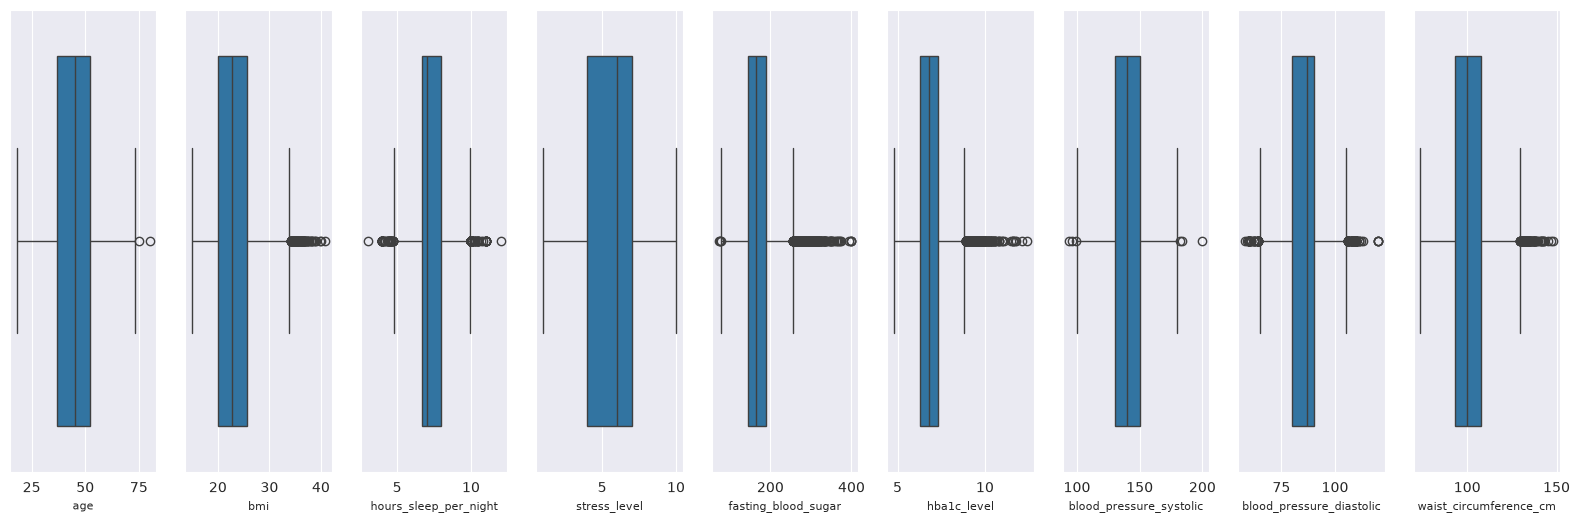

In [94]:
numeric = data.select_dtypes(include=["number"])
N_GRAFICOS = numeric.shape[1]
fig, axes = plt.subplots(ncols=N_GRAFICOS, figsize=(20, 6))
for id, col in enumerate(numeric.columns, 0):
    ax = sns.boxplot(data=data, x=col, ax = axes[id])
    ax.set_xlabel(col, fontsize=8)

Pelos resultados do gráfico, algumas colunas possuem alguns outliers, como "fasting_blood_sugar" e "hba1c_level", e outras são bem distribuídas, como "age" e "stress_level", que vai apenas de 0 a 10.

<Axes: title={'center': 'Matriz de correlação'}>

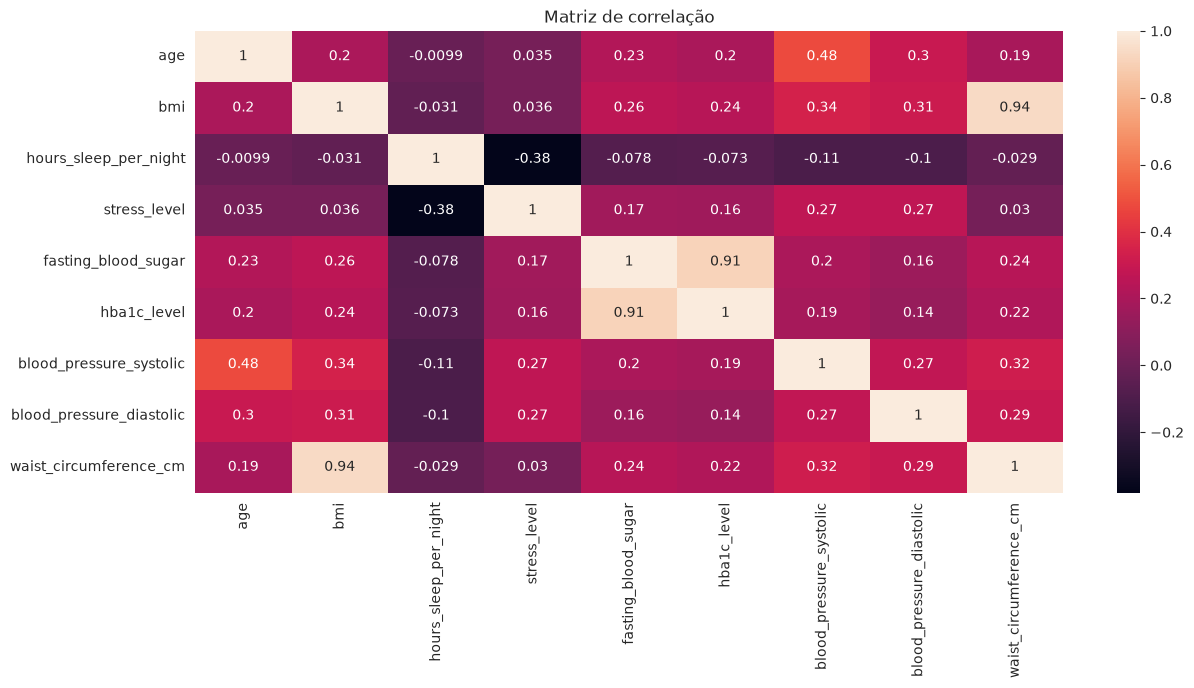

In [95]:
corr_matrix = data.corr(numeric_only=True)
plt.figure(figsize=(14, 6))
plt.title("Matriz de correlação")
sns.heatmap(corr_matrix, annot=True)

Existem algumas correlações bem claras, como uma relação inversamente proporcional entre o nível de estresse e as horas dormidas e a circunferência da cintura com o indíce de massa corporal (bmi).